IMPORTING THE LIBRARIES

In [30]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Iris dataset
from sklearn.datasets import load_iris

# Train/test split
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Feature scaling
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


Loading The Dataset

In [2]:
iris = load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [3]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [14]:
df=pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)
df.head()
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

df["species"] = iris.target
species_mapping = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species"] = df["species"].map(species_mapping)

EXPLORATORY DATA ANALYSIS

Dataset Shape

In [8]:
df.shape

(150, 4)

Data Types

In [9]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

DataSet Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


Null Value Check

In [11]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Descriptive Statistics

In [12]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Visualizations

Pairplot

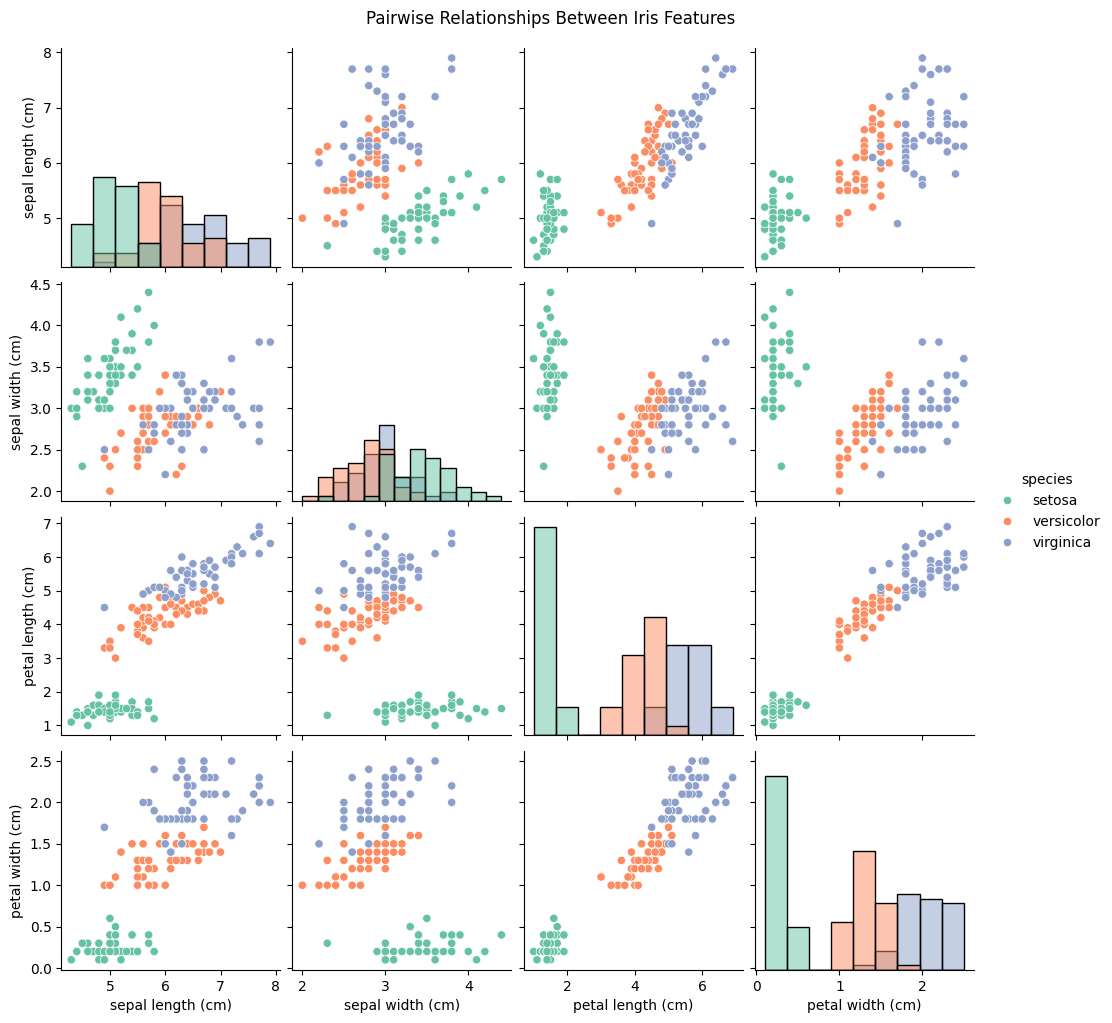

In [16]:
sns.pairplot(
    df,
    hue="species",
    palette="Set2",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships Between Iris Features",
    y=1.02
)

plt.show()

Box plots for each feature

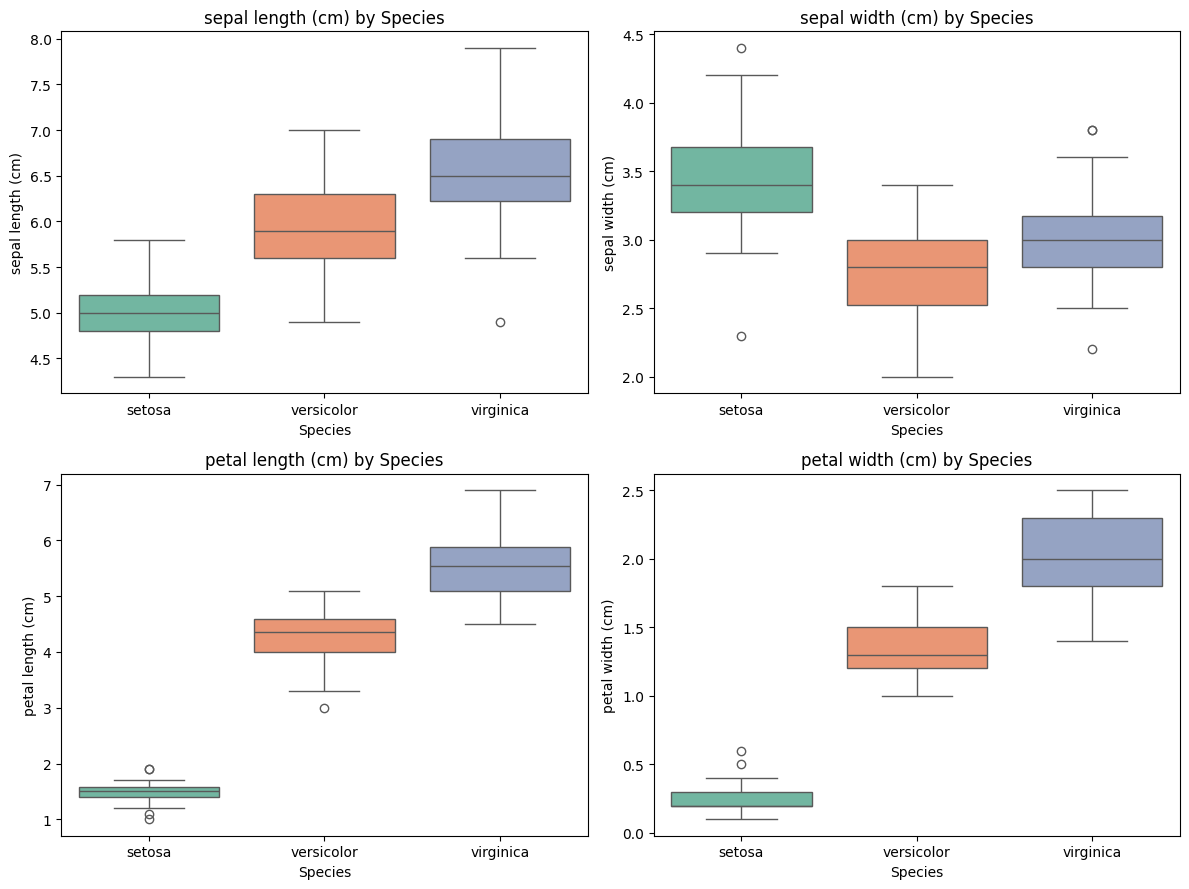

In [17]:
# List of numerical features
features = iris.feature_names

# Create a 2x2 grid of box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        hue="species",
        palette="Set2",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Species")
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

Correlation analysis

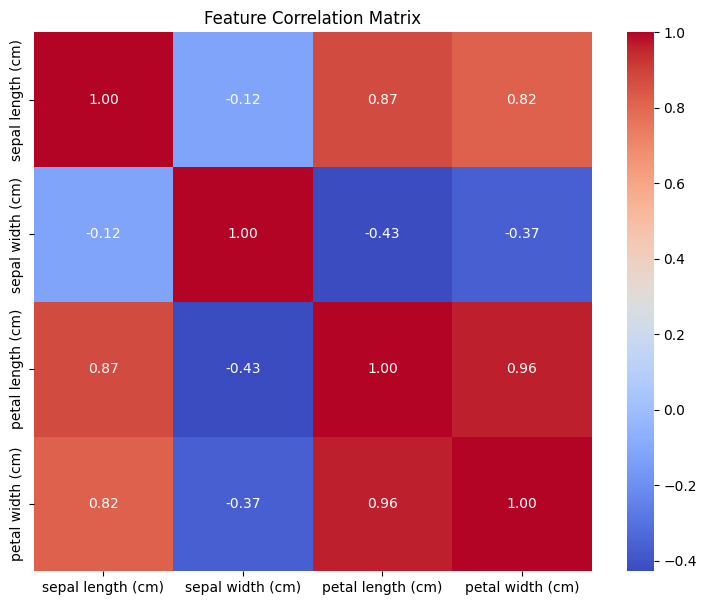

In [18]:
# Calculate correlation matrix for numerical variables
correlation_matrix = df[features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

Feature selection discussion

In [27]:
print("RandomForestClassifier imported successfully!")

RandomForestClassifier imported successfully!


In [32]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

# Separate features and target
X = df[features]
y = df["species"]

# Train Random Forest
rf_feature_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_feature_model.fit(X, y)

# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_feature_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
2  petal length (cm)    0.459290
3   petal width (cm)    0.417860
0  sepal length (cm)    0.101969
1   sepal width (cm)    0.020881


Visualize

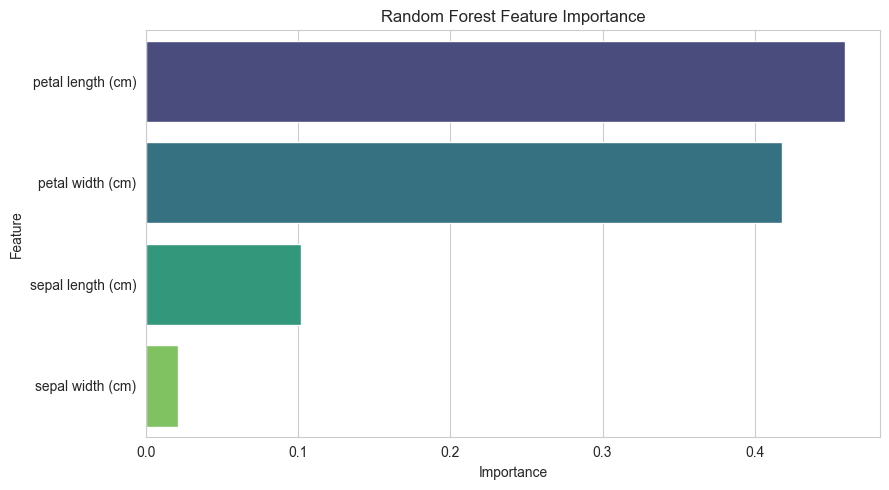

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Train/Test Split

In [34]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


Classifier 1 — Logistic Regression

In [35]:
# ==========================================
# MODEL 1: LOGISTIC REGRESSION
# ==========================================

# Standardize the features before Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=200,
            random_state=42
        )
    )
])

# Train model
logistic_model.fit(
    X_train,
    y_train
)

# Make predictions
y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    f"Logistic Regression Accuracy: "
    f"{lr_accuracy:.4f}"
)

Logistic Regression Accuracy: 0.9333


Logistic Regression Classification Report

In [36]:
# ==========================================
# LOGISTIC REGRESSION REPORT
# ==========================================

print("Logistic Regression Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Logistic Regression Confusion Matrix

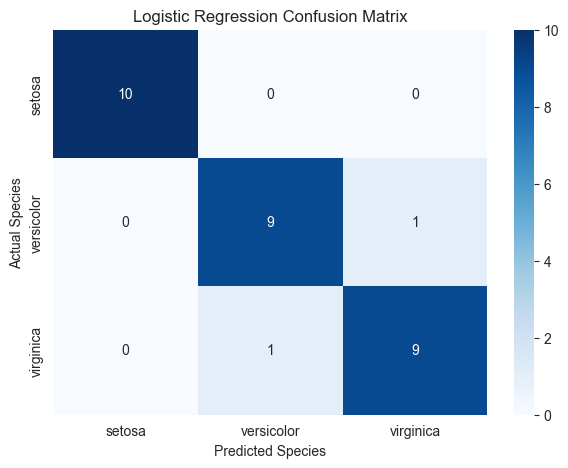

In [38]:
# ==========================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ==========================================

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=iris.target_names
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

Classifier 2 — Random Forest

In [41]:
# ==========================================
# MODEL 2: RANDOM FOREST
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model
rf_model.fit(
    X_train,
    y_train
)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy:.4f}"
)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Random Forest Accuracy: 0.9000


Random Forest Classification Report

In [42]:
# ==========================================
# RANDOM FOREST REPORT
# ==========================================

print("Random Forest Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Random Forest Confusion Matrix

# ==========================================
# RANDOM FOREST CONFUSION MATRIX
# ==========================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=iris.target_names
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

Compare the Two Models

In [44]:
# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.933333
1        Random Forest  0.900000


Visualize

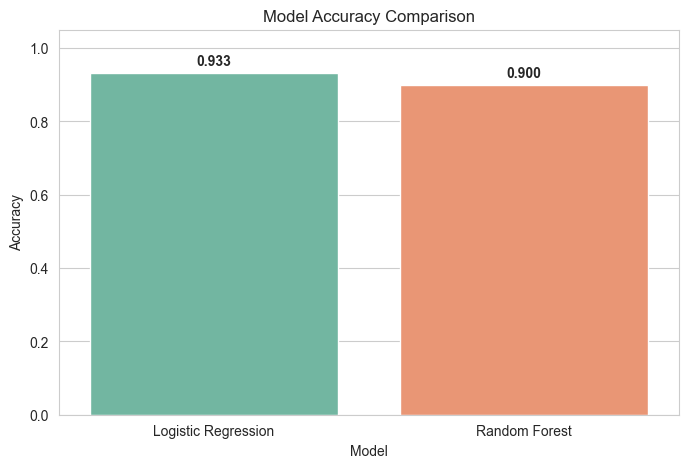

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.ylim(0, 1.05)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, accuracy in enumerate(results["Accuracy"]):

    plt.text(
        i,
        accuracy + 0.02,
        f"{accuracy:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.show()

Identify the Best Model

In [46]:
# ==========================================
# BEST-PERFORMING MODEL
# ==========================================

best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best-performing model:")
print(best_model["Model"])

print(
    f"Accuracy: {best_model['Accuracy']:.4f}"
)

Best-performing model:
Logistic Regression
Accuracy: 0.9333


Final Model Evaluation Comparison

In [47]:
# ==========================================
# DETAILED MODEL COMPARISON
# ==========================================

lr_report = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Logistic Regression": [
        lr_accuracy,
        lr_report["weighted avg"]["precision"],
        lr_report["weighted avg"]["recall"],
        lr_report["weighted avg"]["f1-score"]
    ],

    "Random Forest": [
        rf_accuracy,
        rf_report["weighted avg"]["precision"],
        rf_report["weighted avg"]["recall"],
        rf_report["weighted avg"]["f1-score"]
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.933333,0.900000
1,Precision,0.933333,0.902357
2,Recall,0.933333,0.900000
3,F1-Score,0.933333,0.899749


Final Conclusion

# Final Conclusion

The Iris dataset was successfully loaded using the
`sklearn.datasets.load_iris()` function without downloading any
external data.

Exploratory Data Analysis showed that the dataset contains 150
observations and five columns: four numerical flower measurements and
one target variable representing the species. The dataset contains no
missing values and all three species are equally represented.

The pairplot and box plots demonstrated that petal length and petal
width are the most discriminative features. These features provide
strong separation between Setosa, Versicolor, and Virginica. Sepal
width was comparatively less discriminative.

An 80/20 train/test split was used to evaluate the models.

Two machine learning classifiers were trained:

1. Logistic Regression
2. Random Forest

Both models were evaluated using accuracy, confusion matrices,
precision, recall, and F1-score.

The model comparison shows which classifier achieved the highest
test-set accuracy. That model is selected as the best-performing model.

The Iris dataset is relatively small and the species are well
separated, so both models are expected to achieve very high
classification performance. Random Forest also provides useful feature
importance information, which supports the conclusion that petal
length and petal width are highly discriminative features.